In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [1]:
!git clone https://github.com/mnunez97/aprendizaje_supervisado_resuelto


Cloning into 'aprendizaje_supervisado_resuelto'...
remote: Enumerating objects: 20, done.
remote: Counting objects: 100% (15/15), done.
remote: Compressing objects: 100% (11/11), done.
remote: Total 20 (delta 7), reused 4 (delta 4), pack-reused 5 (from 1)
Receiving objects: 100% (20/20), 75.09 KiB | 3.95 MiB/s, done.
Resolving deltas: 100% (7/7), done.


In [4]:
df = pd.read_csv('aprendizaje_supervisado_resuelto/data/titanic.csv')

In [5]:
df.sample(4)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
47,48,1,3,"O'Driscoll, Miss. Bridget",female,NaN,0,0,14311,7.7500,NaN,Q
543,544,1,2,"Beane, Mr. Edward",male,32.0,1,0,2908,26.0000,NaN,S
881,882,0,3,"Markun, Mr. Johann",male,33.0,0,0,349257,7.8958,NaN,S
867,868,0,1,"Roebling, Mr. Washington Augustus II",male,31.0,0,0,PC 17590,50.4958,A24,S


In [6]:
df['Survived'].value_counts()

,count
Survived,
0,549
1,342


In [7]:
v

NameError: name 'v' is not defined

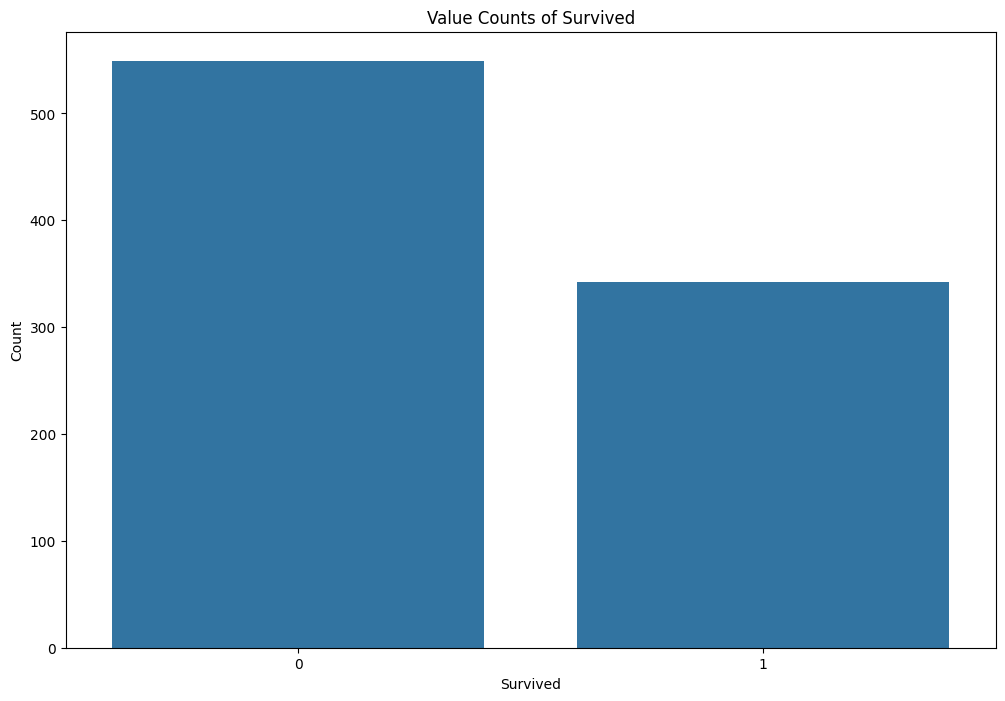

In [8]:
plt.figure(figsize=(12, 8))

sns.barplot(x = df['Survived'].value_counts().index, y = df['Survived'].value_counts())
plt.title('Value Counts of Survived')
plt.xlabel('Survived')
plt.ylabel('Count')
plt.show()

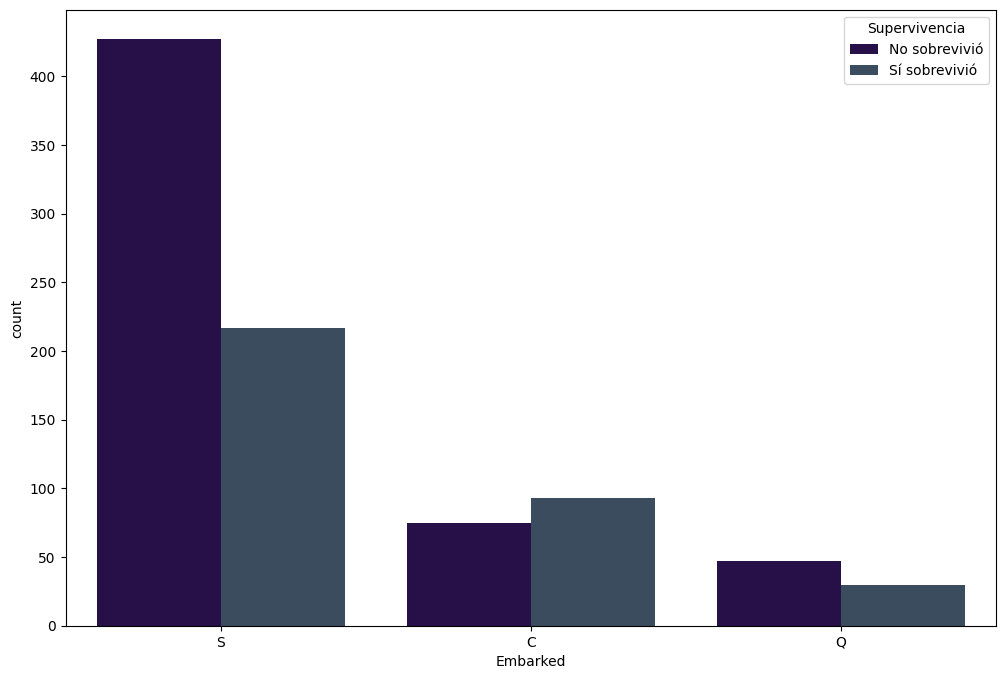

In [9]:
plt.figure(figsize = (12, 8))

# colores para cada una de las clases
color = ['#240750', '#344C64']

sns.countplot(df, x = 'Embarked', hue = 'Survived', palette=color)
plt.legend(title = 'Supervivencia', labels = ['No sobrevivió', 'Sí sobrevivió'])
plt.show()

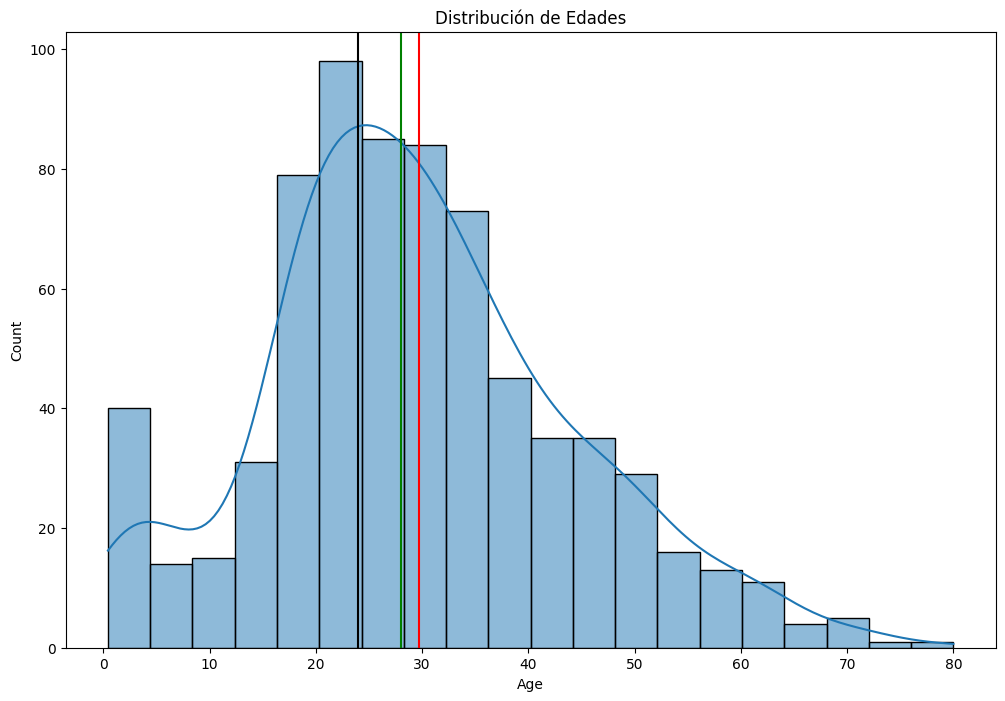

Media: 29.69911764705882
Mediana: 28.0
Moda: 24.0


In [10]:
plt.figure(figsize = (12, 8))

sns.histplot(df, x = 'Age', kde = True)
plt.title('Distribución de Edades')
plt.axvline(df['Age'].mean(), color = 'red')
plt.axvline(df['Age'].median(), color = 'green')
plt.axvline(df['Age'].mode()[0], color = 'black')
plt.show()

# Print the results
print(f"Media: {df['Age'].mean()}")
print(f"Mediana: {df['Age'].median()}")
print(f"Moda: {df['Age'].mode()[0]}")

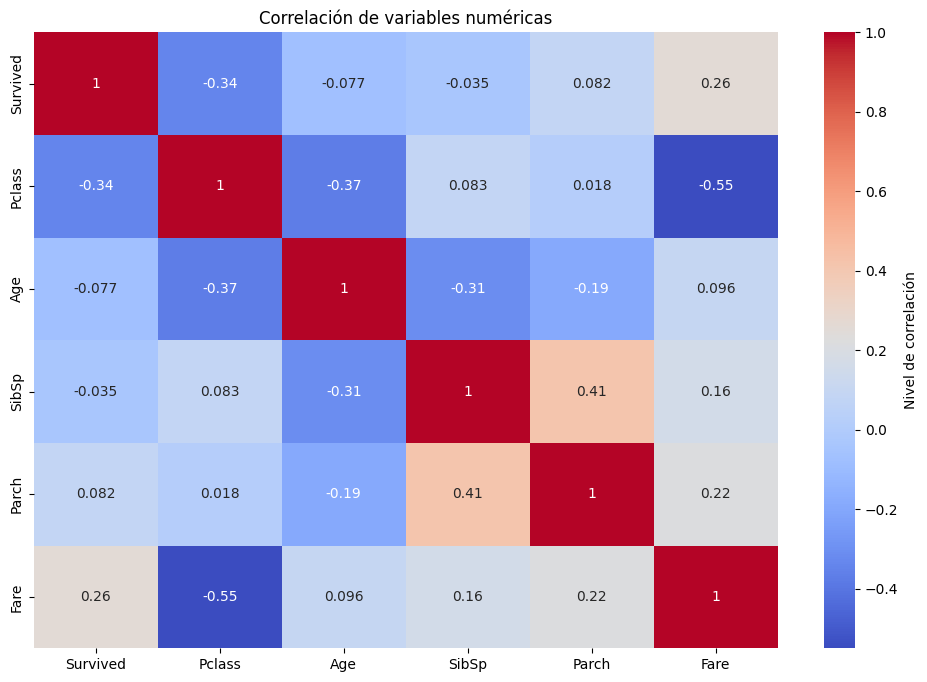

In [11]:
plt.figure(figsize = (12, 8))
sns.heatmap(df[['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']].corr(),
            annot=True,
            cbar=True,  # Activar la barra de colores
            cmap='coolwarm',  # Cambiar la paleta de colores
            cbar_kws={'label': 'Nivel de correlación'})  # Etiqueta para la barra de colores
plt.title('Correlación de variables numéricas')
plt.show()

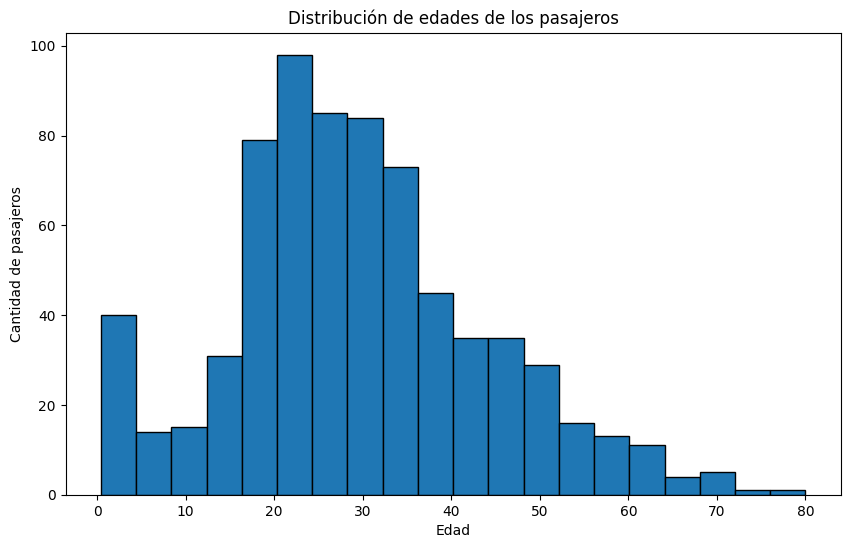

In [12]:
plt.figure(figsize=(10, 6))

df["Age"].dropna().plot(
    kind="hist",
    bins=20,
    edgecolor="black"
)

plt.title("Distribución de edades de los pasajeros")
plt.xlabel("Edad")
plt.ylabel("Cantidad de pasajeros")

plt.show()

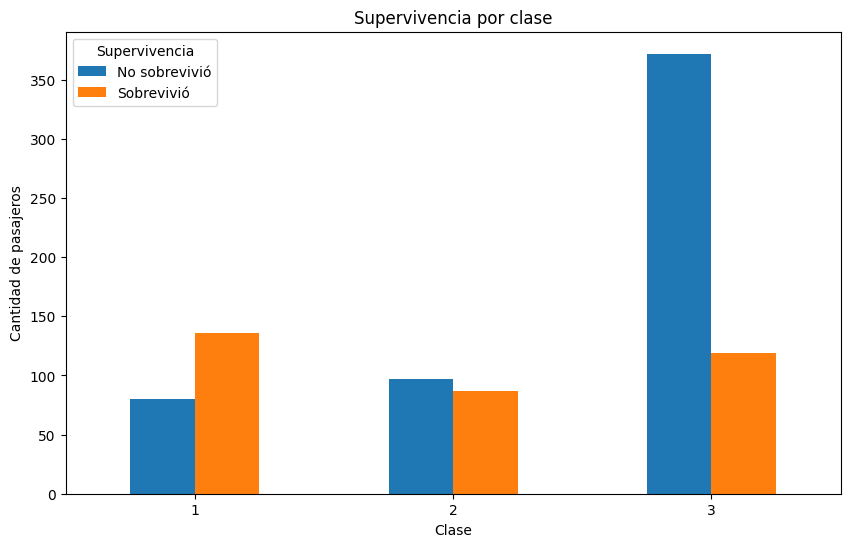

In [13]:
datos = pd.crosstab(df["Pclass"], df["Survived"])

datos.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Supervivencia por clase")
plt.xlabel("Clase")
plt.ylabel("Cantidad de pasajeros")
plt.xticks(rotation=0)

plt.legend(
    ["No sobrevivió", "Sobrevivió"],
    title="Supervivencia"
)

plt.show()

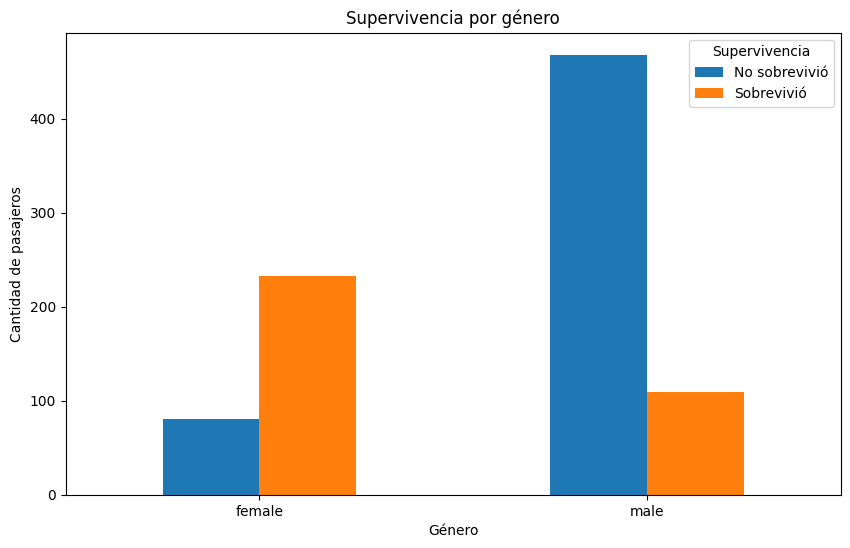

In [14]:
datos = pd.crosstab(df["Sex"], df["Survived"])

datos.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Supervivencia por género")
plt.xlabel("Género")
plt.ylabel("Cantidad de pasajeros")
plt.xticks(rotation=0)

plt.legend(
    ["No sobrevivió", "Sobrevivió"],
    title="Supervivencia"
)

plt.show()

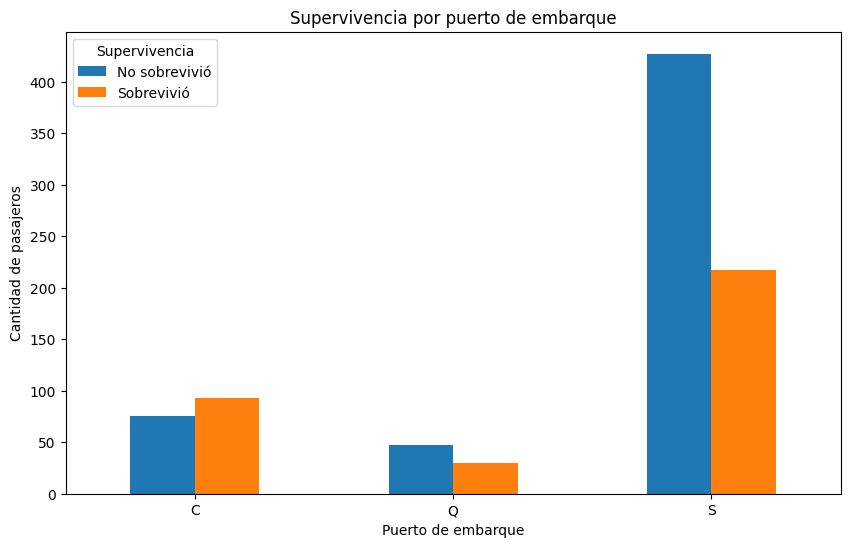

In [15]:
datos = pd.crosstab(df["Embarked"], df["Survived"])

datos.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Supervivencia por puerto de embarque")
plt.xlabel("Puerto de embarque")
plt.ylabel("Cantidad de pasajeros")
plt.xticks(rotation=0)

plt.legend(
    ["No sobrevivió", "Sobrevivió"],
    title="Supervivencia"
)

plt.show()

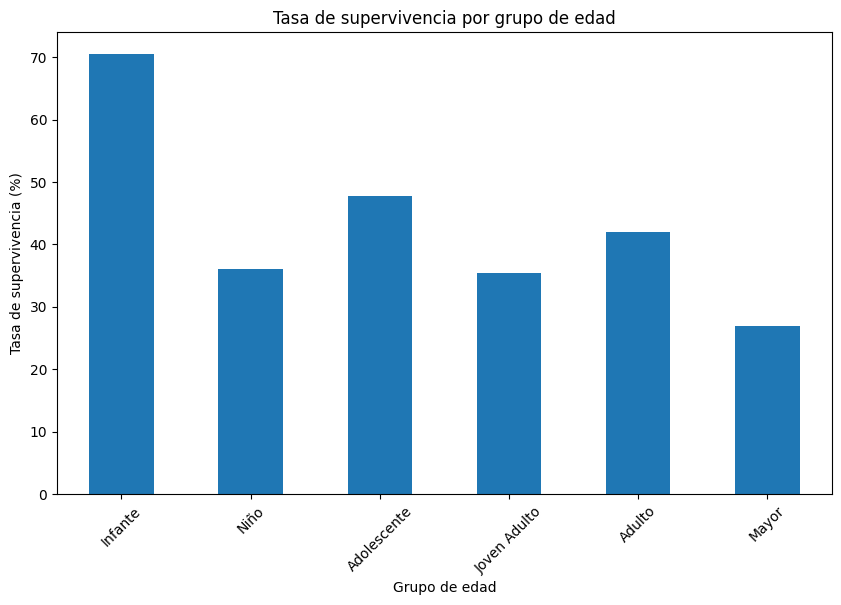

In [16]:
bins = [0, 5, 12, 17, 30, 59, float("inf")]

etiquetas = [
    "Infante",
    "Niño",
    "Adolescente",
    "Joven Adulto",
    "Adulto",
    "Mayor"
]

df["GrupoEdad"] = pd.cut(
    df["Age"],
    bins=bins,
    labels=etiquetas,
    include_lowest=True
)

tasa_supervivencia = df.groupby(
    "GrupoEdad",
    observed=False
)["Survived"].mean() * 100

tasa_supervivencia.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Tasa de supervivencia por grupo de edad")
plt.xlabel("Grupo de edad")
plt.ylabel("Tasa de supervivencia (%)")
plt.xticks(rotation=45)

plt.show()

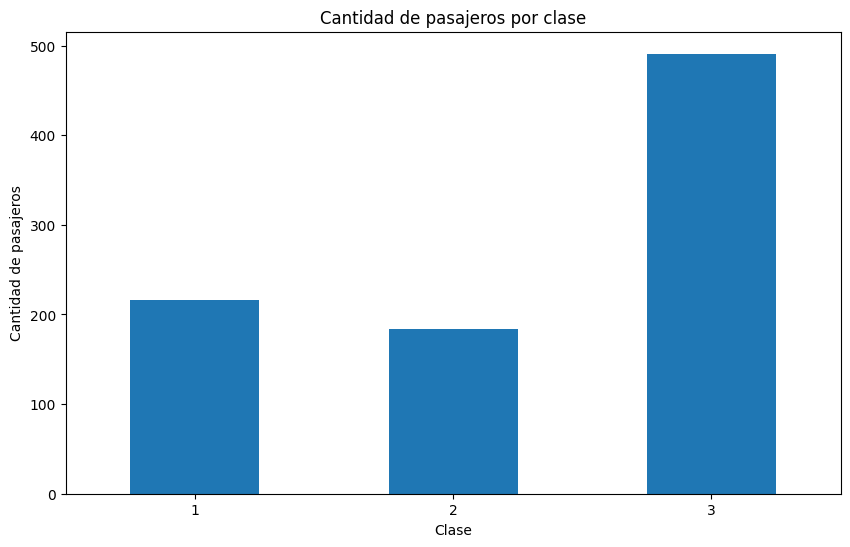

In [17]:
conteo_clases = df["Pclass"].value_counts().sort_index()

conteo_clases.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Cantidad de pasajeros por clase")
plt.xlabel("Clase")
plt.ylabel("Cantidad de pasajeros")
plt.xticks(rotation=0)

plt.show()

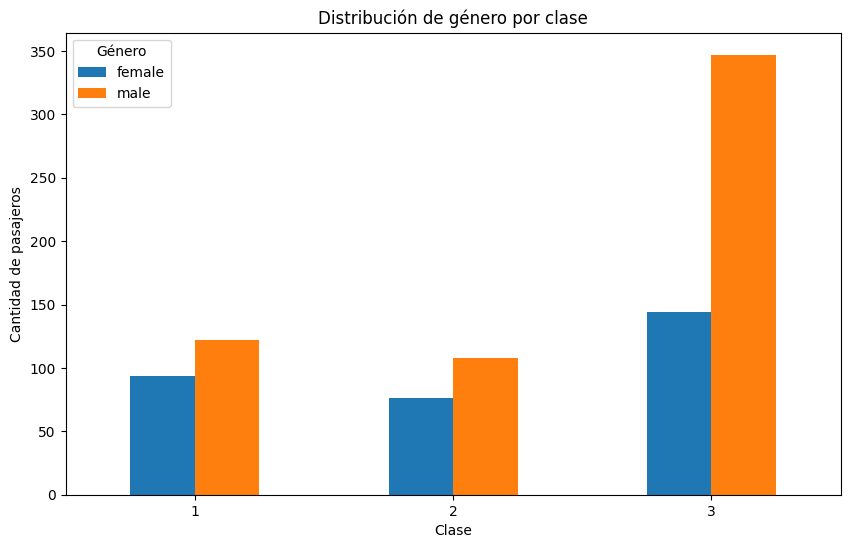

In [18]:
datos = pd.crosstab(df["Pclass"], df["Sex"])

datos.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Distribución de género por clase")
plt.xlabel("Clase")
plt.ylabel("Cantidad de pasajeros")
plt.xticks(rotation=0)

plt.legend(title="Género")

plt.show()

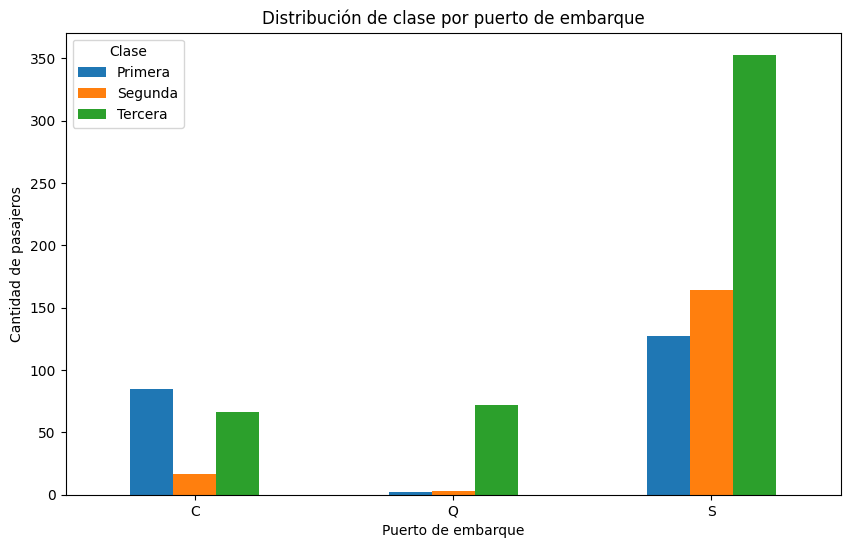

In [19]:
datos = pd.crosstab(df["Embarked"], df["Pclass"])

datos.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Distribución de clase por puerto de embarque")
plt.xlabel("Puerto de embarque")
plt.ylabel("Cantidad de pasajeros")
plt.xticks(rotation=0)

plt.legend(
    title="Clase",
    labels=["Primera", "Segunda", "Tercera"]
)

plt.show()